In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import nan
plt.rcParams["figure.figsize"] = (30,4)

path = "/data2/yh/highres.sampling_two_exchange_v5/data/DOTUSDT_orders.csv"
norders = pd.read_csv(path, header = None)
norders.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen","fkey","b","a"]
# norders = norders[["oid", "cts", "uts", "side", "sid", "price", "amount", "famount", "fkey"]]


In [20]:
norders.head(5)

,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
0,op_oask:0:1_0.0002_-1_1_1_49,1719878409000,1719878425251,op_oask:0:1_0.0002_-1_1_1_49,DOTUSDT,maker,0,sell,6.330,7.902015,7.902015,filled,0.0,134.0,ask:0:1:0.0002:-1:1:1:1719878409,6.329,6.330
1,op_oask:0:1_0.0002_-1_1_1_21,1719878405000,1719878426692,op_oask:0:1_0.0002_-1_1_1_21,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.0,6.0,ask:0:1:0.0002:-1:1:1:1719878405,6.330,6.331
2,op_oask:0:1_0.0002_-1_1_1_28,1719878406000,1719878426692,op_oask:0:1_0.0002_-1_1_1_28,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.0,6.0,ask:0:1:0.0002:-1:1:1:1719878406,6.330,6.331
3,op_oask:0:1_0.0002_-1_1_1_35,1719878407000,1719878426692,op_oask:0:1_0.0002_-1_1_1_35,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.0,6.0,ask:0:1:0.0002:-1:1:1:1719878407,6.330,6.331
4,op_oask:0:1_0.0002_-1_1_1_42,1719878408000,1719878426692,op_oask:0:1_0.0002_-1_1_1_42,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.0,6.0,ask:0:1:0.0002:-1:1:1:1719878408,6.330,6.331


In [21]:
n_open = norders[(norders["fkey"].str.startswith("bid")) | (norders["fkey"].str.startswith("ask"))]
n_close = norders[norders["fkey"].str.startswith("cl")]

In [22]:
n_open

,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
0,op_oask:0:1_0.0002_-1_1_1_49,1719878409000,1719878425251,op_oask:0:1_0.0002_-1_1_1_49,DOTUSDT,maker,0,sell,6.330,7.902015,7.902015,filled,0.000000e+00,134.0,ask:0:1:0.0002:-1:1:1:1719878409,6.329,6.330
1,op_oask:0:1_0.0002_-1_1_1_21,1719878405000,1719878426692,op_oask:0:1_0.0002_-1_1_1_21,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878405,6.330,6.331
2,op_oask:0:1_0.0002_-1_1_1_28,1719878406000,1719878426692,op_oask:0:1_0.0002_-1_1_1_28,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878406,6.330,6.331
3,op_oask:0:1_0.0002_-1_1_1_35,1719878407000,1719878426692,op_oask:0:1_0.0002_-1_1_1_35,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878407,6.330,6.331
4,op_oask:0:1_0.0002_-1_1_1_42,1719878408000,1719878426692,op_oask:0:1_0.0002_-1_1_1_42,DOTUSDT,maker,0,sell,6.331,7.900766,5.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878408,6.330,6.331
5,op_oask:0:1_0.0004_-1_1_1_50,1719878409000,1719878426692,op_oask:0:1_0.0004_-1_1_1_50,DOTUSDT,maker,0,sell,6.331,7.902015,5.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0004:-1:1:1:1719878409,6.330,6.331
6,op_oask:0:1_0.0002_-1_1_1_21,1719878405000,1719878426692,op_oask:0:1_0.0002_-1_1_1_21,DOTUSDT,maker,0,sell,6.331,7.900766,1.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878405,6.330,6.331
7,op_oask:0:1_0.0002_-1_1_1_28,1719878406000,1719878426692,op_oask:0:1_0.0002_-1_1_1_28,DOTUSDT,maker,0,sell,6.331,7.900766,1.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878406,6.330,6.331
8,op_oask:0:1_0.0002_-1_1_1_35,1719878407000,1719878426692,op_oask:0:1_0.0002_-1_1_1_35,DOTUSDT,maker,0,sell,6.331,7.900766,1.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878407,6.330,6.331
9,op_oask:0:1_0.0002_-1_1_1_42,1719878408000,1719878426692,op_oask:0:1_0.0002_-1_1_1_42,DOTUSDT,maker,0,sell,6.331,7.900766,1.000000,partial_filled,0.000000e+00,6.0,ask:0:1:0.0002:-1:1:1:1719878408,6.330,6.331


In [24]:
n_open["diff_ts"] = n_open["uts"] - n_open["cts"]

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.


In [26]:
n_open[n_open["diff_ts"] > 120 * 1000]

,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a,diff_ts
38434,op_obid:0:1_0.0002_1_1_1_729600,1720065480000,1720065600151,op_obid:0:1_0.0002_1_1_1_729600,DOTUSDT,maker,0,buy,5.908,8.459521,8.459521,filled,0.006253,922.0,bid:0:1:0.0002:1:1:1:1720065480,5.908,5.909,120151
38444,op_obid:0:1_0.0004_1_1_1_729601,1720065480000,1720065600225,op_obid:0:1_0.0004_1_1_1_729601,DOTUSDT,maker,0,buy,5.907,8.459521,8.459521,filled,0.000148,1815.0,bid:0:1:0.0004:1:1:1:1720065480,5.908,5.909,120225
76316,op_obid:0:1_0.0002_1_1_1_1345654,1720305130000,1720305250001,op_obid:0:1_0.0002_1_1_1_1345654,DOTUSDT,maker,0,buy,6.210,8.048290,3.000000,partial_filled,0.000000,29.0,bid:0:1:0.0002:1:1:1:1720305130,6.210,6.211,120001


In [27]:
=

120151

In [23]:
n_open[n_open["sid"] == 1]

,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a


In [8]:
n_close

,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
156,cbid_m_0_1_1_0.0003_1062,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1062,DOTUSDT,maker,1,buy,6.331,7.900766,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878405,6.331,6.332
157,cbid_m_0_1_1_0.0003_1065,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1065,DOTUSDT,maker,1,buy,6.331,7.900766,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878415,6.331,6.332
158,cbid_m_0_1_1_0.0003_1067,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1067,DOTUSDT,maker,1,buy,6.331,7.900766,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878416,6.331,6.332
159,cbid_m_0_1_1_0.0003_1068,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1068,DOTUSDT,maker,1,buy,6.331,7.900766,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878424,6.331,6.332
160,cbid_m_0_1_1_0.0003_1069,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1069,DOTUSDT,maker,1,buy,6.331,7.902015,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878409,6.331,6.332
161,cbid_m_0_1_1_0.0003_1070,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1070,DOTUSDT,maker,1,buy,6.331,7.902015,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878410,6.331,6.332
162,cbid_m_0_1_1_0.0003_1071,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1071,DOTUSDT,maker,1,buy,6.331,7.902015,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878414,6.331,6.332
163,cbid_m_0_1_1_0.0003_1074,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1074,DOTUSDT,maker,1,buy,6.331,7.902015,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878411,6.331,6.332
164,cbid_m_0_1_1_0.0003_1077,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1077,DOTUSDT,maker,1,buy,6.331,7.902015,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878419,6.331,6.332
165,cbid_m_0_1_1_0.0003_1084,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1084,DOTUSDT,maker,1,buy,6.331,7.899518,7.000000,partial_filled,0.000000,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878404,6.331,6.332


In [11]:
norders[norders["oid"] == "op_oask:0:1_0_-1_1_1_50"]


,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
0,op_oask:0:1_0_-1_1_1_50,1719878412000,1719878413419,op_oask:0:1_0_-1_1_1_50,DOTUSDT,maker,0,sell,6.327,7.903264,7.903264,filled,0.0,2.0,ask:0:1:0:-1:1:1:1719878412,6.326,6.327


In [12]:
norders[norders["fkey"] == "cl_1_ask:0:1:0:-1:1:1:1719878412"]




,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
283,cbid_m_0_1_1_0.0003_4151,1719878476000,1719878490362,cbid_m_0_1_1_0.0003_4151,DOTUSDT,maker,1,buy,6.335,7.903264e+00,1.600000e+00,partial_filled,0.0,273.0,cl_1_ask:0:1:0:-1:1:1:1719878412,6.335,6.336
287,cbid_m_0_1_1_0.0003_4151,1719878476000,1719878490362,cbid_m_0_1_1_0.0003_4151,DOTUSDT,maker,1,buy,6.335,7.903264e+00,6.000000e+00,partial_filled,0.0,273.0,cl_1_ask:0:1:0:-1:1:1:1719878412,6.335,6.336
291,cbid_m_0_1_1_0.0003_4151,1719878476000,1719878490362,cbid_m_0_1_1_0.0003_4151,DOTUSDT,maker,1,buy,6.335,7.903264e+00,3.032640e-01,filled,0.0,273.0,cl_1_ask:0:1:0:-1:1:1:1719878412,6.335,6.336
533,cbid_m_0_1_1_0.0003_7272,1719878522000,1719878535050,cbid_m_0_1_1_0.0003_7272,DOTUSDT,maker,1,buy,6.331,8.881784e-16,8.881784e-16,filled,906.7,0.0,cl_1_ask:0:1:0:-1:1:1:1719878412,6.328,6.329


In [14]:
norders[norders["fkey"] == "cl_1_ask:0:1:0:-1:1:1:1719878412"]["famount"].sum()

7.903264048051846

In [15]:
norders[norders["oid"] == "cbid_m_0_1_1_0.0003_1062"]


,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
156,cbid_m_0_1_1_0.0003_1062,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1062,DOTUSDT,maker,1,buy,6.331,7.900766,7.000000,partial_filled,0.0,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878405,6.331,6.332
177,cbid_m_0_1_1_0.0003_1062,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1062,DOTUSDT,maker,1,buy,6.331,7.900766,0.800000,partial_filled,0.0,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878405,6.331,6.332
198,cbid_m_0_1_1_0.0003_1062,1719878440000,1719878440617,cbid_m_0_1_1_0.0003_1062,DOTUSDT,maker,1,buy,6.331,7.900766,0.100766,filled,0.0,44.7,cl_1_ask:0:1:0.001:-1:1:1:1719878405,6.331,6.332


In [16]:
norders[norders["fkey"] == "ask:0:1:0.001:-1:1:1:1719878405"]


,oid,cts,uts,oid2,symbol,ttype,sid,side,price,amount,famount,status,inpos,tlen,fkey,b,a
135,op_oask:0:1_0.001_-1_1_1_18,1719878405000,1719878439400,op_oask:0:1_0.001_-1_1_1_18,DOTUSDT,maker,0,sell,6.336,7.900766,7.900766,filled,0.0,239.0,ask:0:1:0.001:-1:1:1:1719878405,6.335,6.336


In [16]:
open_norders = norders[norders["oid"].str.startswith("o")]
close_norders = norders[norders["oid"].str.startswith("c")]

ss = open_norders.groupby("fkey")["uts"].min().reset_index()
ss.columns = ["fkey", "start_close_ts"]
close_norders["fkey"] = close_norders["fkey"].str.split("_", expand=True)[1]
se = close_norders.groupby("fkey")["uts"].max().reset_index()

/usr/local/lib/python3.6/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


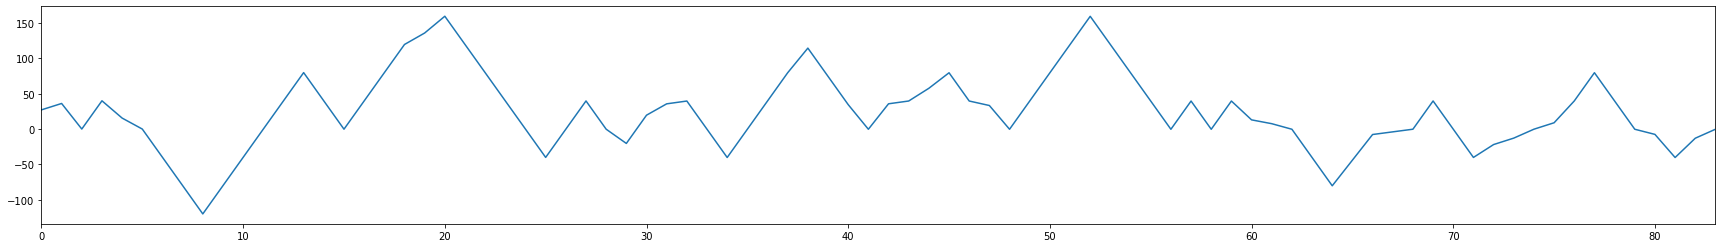

In [17]:
norders.loc[norders["side"] == "buy", "ffamount"] = norders[norders["side"] == "buy"]["famount"]
norders.loc[norders["side"] == "sell", "ffamount"] = -norders[norders["side"] == "sell"]["famount"]
norders["u"] = norders["ffamount"] * norders["price"]

norders["usum"] = norders["u"].cumsum()
norders["usum"].plot()

In [18]:
norders

,oid,cts,uts,side,sid,price,amount,famount,fkey,ffamount,u,usum
0,obid:0:1_0.0002_0,1714869398000,1714869398483,buy,0,9.0457,4.420402,3.000000,bid:0:1:0.0002:1714869398,3.000000,27.137100,27.137100
1,obid:0:1_0.0002_0,1714869398000,1714869398483,buy,0,9.0457,4.420402,1.000000,bid:0:1:0.0002:1714869398,1.000000,9.045700,36.182800
2,cask_m_0_1_1_0.0004_19,1714869435000,1714869435289,sell,1,9.0490,4.000000,4.000000,cl_1_bid:0:1:0.0002:1714869398,-4.000000,-36.196000,-0.013200
3,obid:1:0_0.0002_25,1714869486000,1714869491973,buy,1,9.0480,4.419401,4.419401,bid:1:0:0.0002:1714869486,4.419401,39.986742,39.973542
4,oask:0:1_0.0002_112,1714869496000,1714869502070,sell,0,9.0611,4.415425,2.700000,ask:0:1:0.0002:1714869496,-2.700000,-24.464970,15.508572
5,oask:0:1_0.0002_112,1714869496000,1714869502071,sell,0,9.0611,4.415425,1.715425,ask:0:1:0.0002:1714869496,-1.715425,-15.543640,-0.035068
6,oask:0:1_0.0004_113,1714869496000,1714869503366,sell,0,9.0629,4.415425,4.415425,ask:0:1:0.0004:1714869496,-4.415425,-40.016558,-40.051626
7,oask:0:1_0.0006_114,1714869496000,1714869503805,sell,0,9.0647,4.415425,4.415425,ask:0:1:0.0006:1714869496,-4.415425,-40.024506,-80.076132
8,cask_m_1_0_0_0.0002_319,1714869524000,1714869528008,sell,0,9.0743,4.419401,4.419401,cl_0_bid:1:0:0.0002:1714869486,-4.419401,-40.102972,-120.179104
9,cbid_m_0_1_1_0.0002_420,1714869535000,1714869539932,buy,1,9.0660,4.415425,4.415425,cl_1_ask:0:1:0.0002:1714869496,4.415425,40.030246,-80.148858


In [19]:
norders["fee"] = -0.00005

In [20]:
%run /data2/run/doutdiff/opentable.ipynb

def bt(norder):
    ot = Opentable()
    pfix = 0
    ps = []
    poss = {0:0,1:0,2:0,3:0,4:0}
    n=1

    for row in norder.sort_values("cts").to_dict("records"):
        #if row["status"] == "partial_filled":continue

        if(row["side"] == "buy"):
            p = ot.add("bid", row["price"], row["famount"], row["cts"])
            pfix+=p
            poss[row["sid"]]+=(row["price"] * row["famount"])
            pfix-=(row["fee"] * row["price"] * row["famount"])
        if(row["side"] == "sell"):
            p = ot.drop("ask", row["price"], row["famount"], row["cts"])
            pfix+=p
            poss[row["sid"]]-=(row["price"] * row["famount"])
            pfix-=(row["fee"] * row["price"] * row["famount"])
        openrisk,_l,_l = ot.get_openrisk()
        
        if row["cts"] % 10000 == 0:
            ps.append({
                "ts":row["cts"],
                "pfix":pfix*n,
                "open":openrisk*n*row["price"],
                "poss_0":poss[0]*1,
                "poss_1":poss[1]*1,
                "poss_2":poss[2]*1,
                "poss_3":poss[3]*1,
                "poss_4":poss[4]*1,
            })

    return pd.DataFrame(ps)
nps = bt(norders)

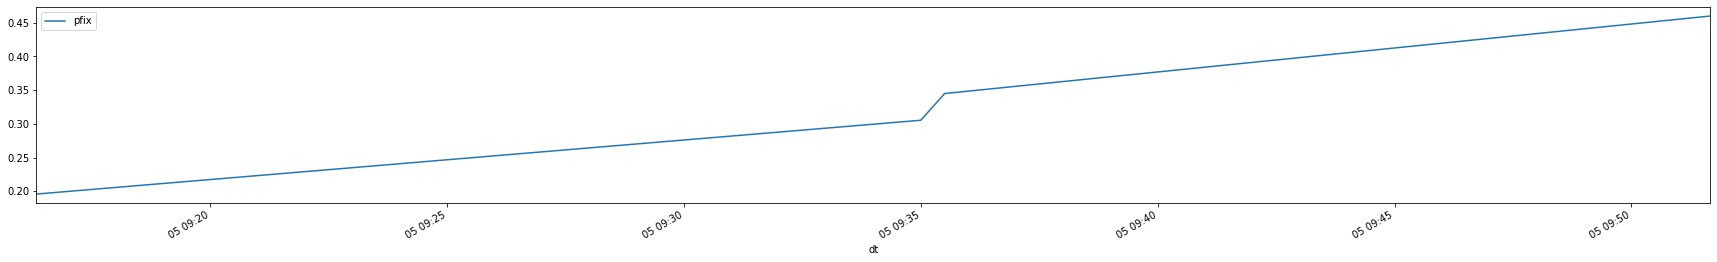

In [21]:
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600000, unit="ms")
nps.plot(x="dt", y="pfix")

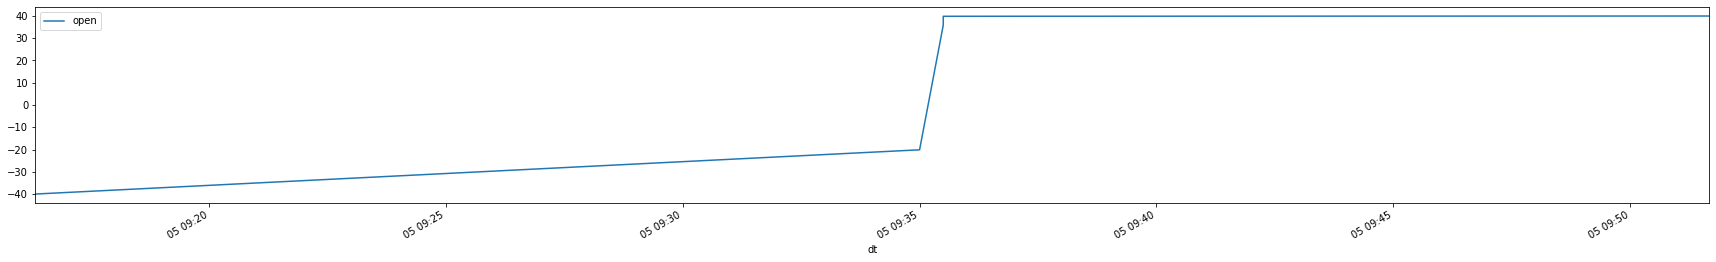

In [22]:
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600000, unit="ms")
nps.plot(x="dt", y="open")